## La side quest di Alice verso un modello sensato

Cambiamo per un attimo il task... facciamo finta che voglio predire il tipo di intervento, dato che secondo me è un dataset sintetico che ti fa fare un solo task, cioè questo. Dato che so stronza rifaccio tutto daccapo

In [2]:
from sklearn.preprocessing import LabelEncoder
from commons import logistic_model_selection, prepare_train_test, plot_confusion_matrix
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns

from scripts.commons import random_forest_model_selection

df = pd.read_csv('../power_nap_vs_coffee_effectiveness_dataset.csv')
df = df.drop("participant_id", axis=1)
df = df.dropna()

#alertness_delta
df["alertness_delta"] = df["alertness_score_after"] - df["alertness_score_before"]
df = df.drop(["alertness_score_after", "alertness_score_before"], axis=1)

#encoding: dummies per le categorie non target, 0 e 1 per i tipi di intervento
df = pd.get_dummies(df, columns=["occupation", "side_effects"])
le = LabelEncoder()
df["intervention_type"] = le.fit_transform(df["intervention_type"])

#Controllo se l'intervento ha funzionato
df.head()

,age,sleep_hours_previous_night,intervention_type,intervention_duration_minutes,productivity_rating,mood_rating,alertness_delta,occupation_Freelancer,occupation_Student,occupation_Working Professional,side_effects_Anxiety,side_effects_Crash,side_effects_Grogginess
0,24,5.4,1,15,5,10,15,False,False,True,False,False,True
2,32,4.4,0,30,2,5,8,False,False,True,True,False,False
3,28,6.9,0,30,4,6,11,False,True,False,False,True,False
4,25,4.7,1,30,3,6,18,False,False,True,False,False,True
7,43,4.4,1,25,5,10,20,False,True,False,False,False,True


Fitting 5 folds for each of 24 candidates, totalling 120 fits
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        24

    accuracy                           1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59


Accuratezza sul Train Set: 1.0000
Accuratezza sul Test Set: 1.0000
LogisticRegression(C=np.float64(0.001), class_weight='balanced', max_iter=2000,
                   penalty='l2', random_state=42)

=== CONFUSION MATRIX ===
[[35  0]
 [ 0 24]]


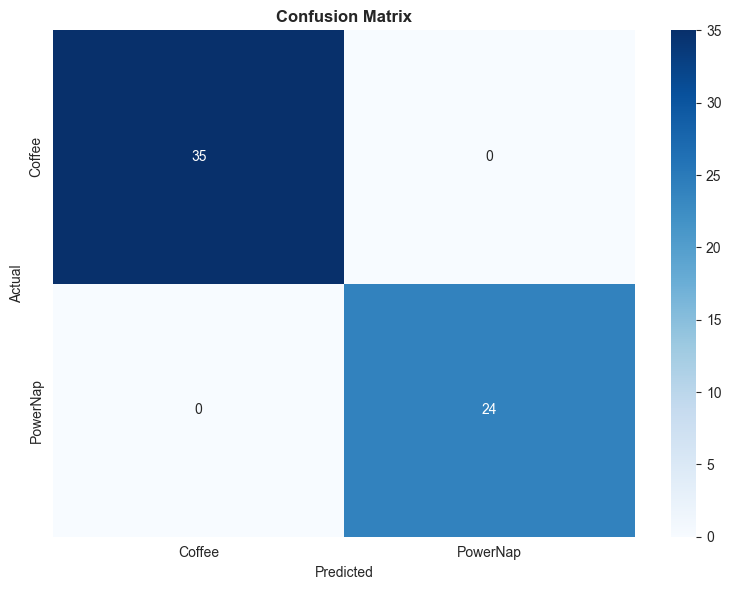

In [5]:
import warnings
warnings.filterwarnings("ignore", message="Inconsistent values*")
warnings.filterwarnings("ignore", category=FutureWarning)

X = df.drop("intervention_type", axis=1)
y = df['intervention_type']

_, X_train, y_train, X_test, y_test = prepare_train_test(X, y)
logistic_regressor, best_params, best_score = logistic_model_selection(X_train, y_train)

y_pred = logistic_regressor.predict(X_test)
print(classification_report(y_test, y_pred))

# Accuratezza su train e test set
train_accuracy = logistic_regressor.score(X_train, y_train)
test_accuracy = logistic_regressor.score(X_test, y_test)

print(f"\nAccuratezza sul Train Set: {train_accuracy:.4f}")
print(f"Accuratezza sul Test Set: {test_accuracy:.4f}")
print(logistic_regressor.best_estimator_)  #per vedere gli iperparametri scelti

cm = confusion_matrix(y_test, y_pred)
labels=['Coffee', 'PowerNap']
print("\n=== CONFUSION MATRIX ===")
print(cm)

plot_confusion_matrix(cm, labels, title="Confusion Matrix")



              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        24

    accuracy                           1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59


Accuratezza sul Train Set: 1.0000
Accuratezza sul Test Set: 1.0000
RandomForestClassifier(max_depth=3, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=50, random_state=42)

=== CONFUSION MATRIX ===
[[35  0]
 [ 0 24]]

=== CONFUSION MATRIX ===
[[35  0]
 [ 0 24]]


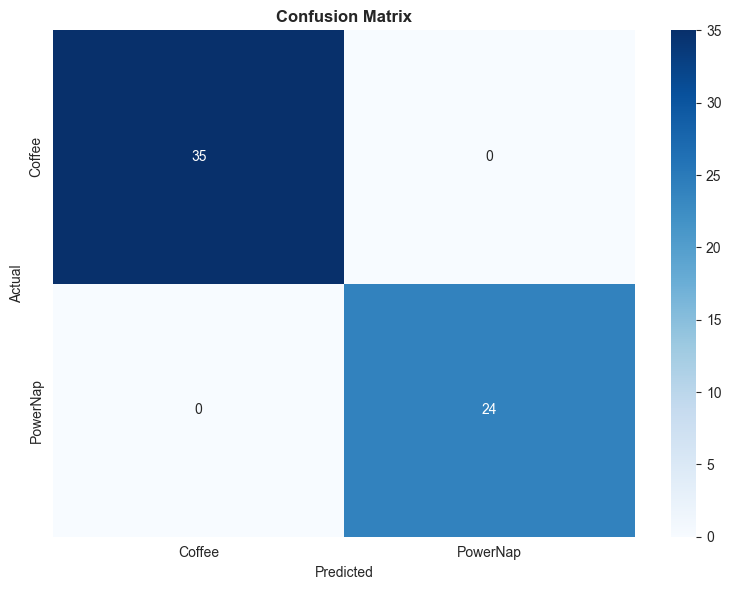

In [6]:

rf_model, best_params, best_score = random_forest_model_selection(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Accuratezza su train e test set
train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print(f"\nAccuratezza sul Train Set: {train_accuracy:.4f}")
print(f"Accuratezza sul Test Set: {test_accuracy:.4f}")
print(rf_model.best_estimator_)  #per vedere gli iperparametri scelti

cm = confusion_matrix(y_test, y_pred)
print("\n=== CONFUSION MATRIX ===")
print(cm)

cm = confusion_matrix(y_test, y_pred)
labels=['Coffee', 'PowerNap']
print("\n=== CONFUSION MATRIX ===")
print(cm)

plot_confusion_matrix(cm, labels, title="Confusion Matrix")


Feature Importance:
                            Feature  Importance
11          side_effects_Grogginess    0.421639
10               side_effects_Crash    0.221307
5                   alertness_delta    0.187484
9              side_effects_Anxiety    0.131249
1        sleep_hours_previous_night    0.011024
4                       mood_rating    0.007724
0                               age    0.006028
7                occupation_Student    0.004655
3               productivity_rating    0.004515
2     intervention_duration_minutes    0.003174
8   occupation_Working Professional    0.000920
6             occupation_Freelancer    0.000282


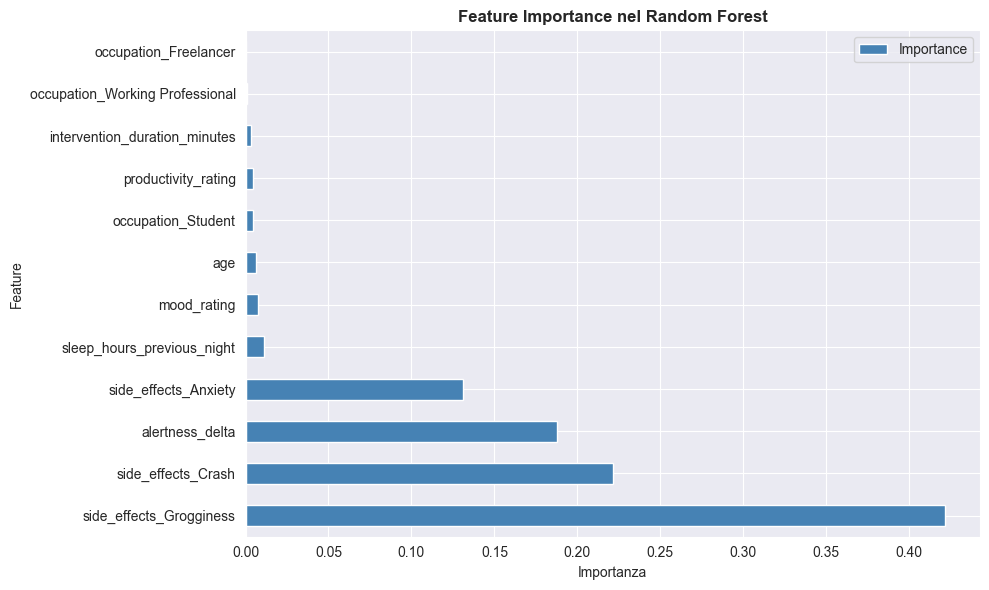

In [7]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Grafico
fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.plot(x='Feature', y='Importance', kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance nel Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importanza')
plt.tight_layout()
plt.show()